In [1]:
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.dpi"] = 120
client = MongoClient("mongodb://localhost:27017")
db = client["sample_supplies"]
sales = db["sales"]

In [2]:
print(f"Database   : {db.name}")
print(f"Collection : {sales.name}")
print(f"Documents  : {sales.count_documents({}):,}")

Database   : sample_supplies
Collection : sales
Documents  : 5,000


Question 1
What is the total number of sales transactions recorded in the dataset?

In [3]:
total_transactions = sales.count_documents({})

print("Total Sales Transactions:", total_transactions)

Total Sales Transactions: 5000


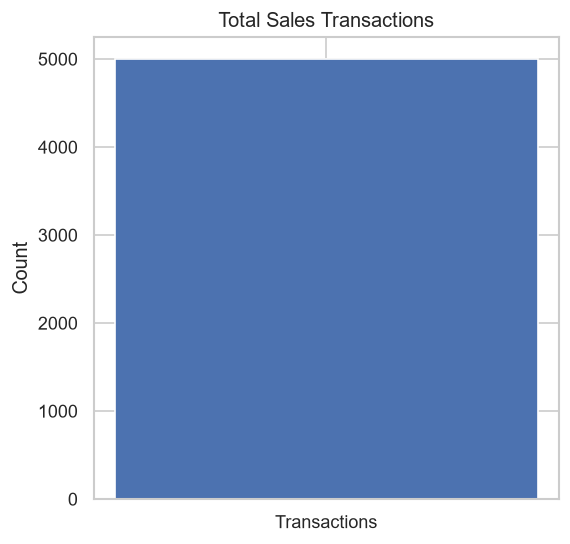

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.bar(["Transactions"], [total_transactions])
plt.title("Total Sales Transactions")
plt.ylabel("Count")
plt.show()

Question 2:How many sales transactions were processed by each store location, and how do the transaction volumes compare across different store locations?

In [5]:
pipeline = [
    {
        "$group": {
            "_id": "$storeLocation",
            "Total_Transactions": {
                "$sum": 1
            }
        }
    },
    {
        "$sort": {
            "Total_Transactions": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

df = pd.DataFrame(result)

df.rename(columns={"_id": "Store Location"}, inplace=True)

print(df)

  Store Location  Total_Transactions
0         Denver                1549
1        Seattle                1134
2         London                 794
3         Austin                 676
4       New York                 501
5      San Diego                 346


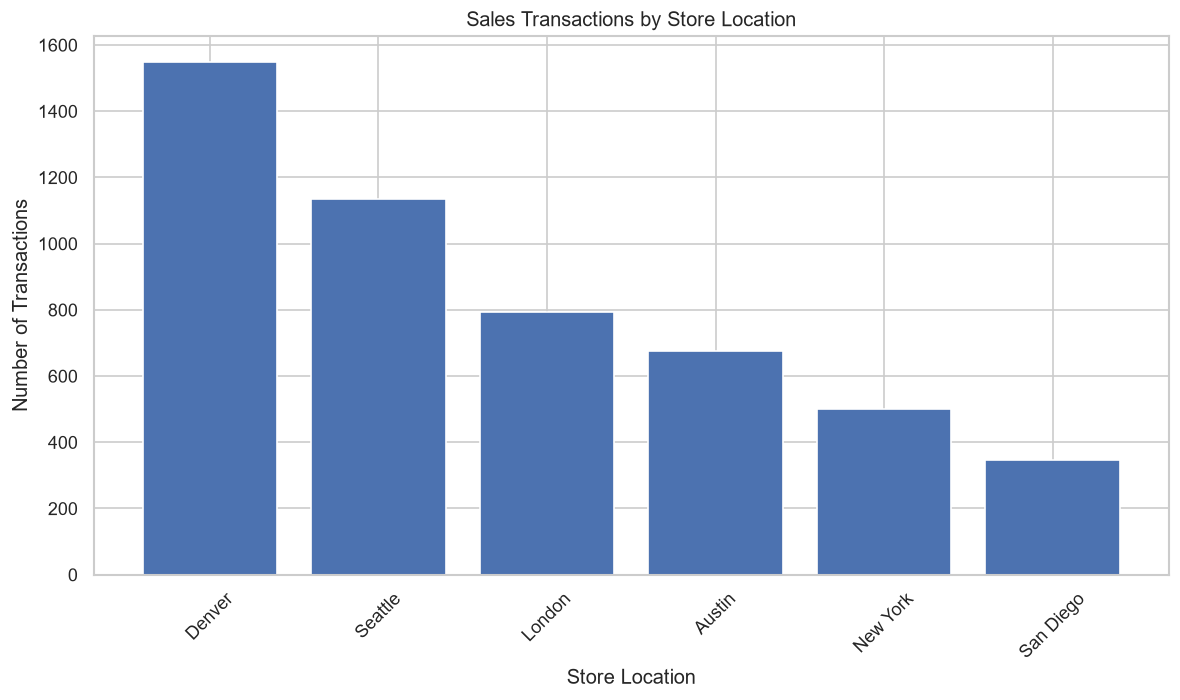

In [6]:
plt.figure(figsize=(10,6))

plt.bar(df["Store Location"], df["Total_Transactions"])

plt.title("Sales Transactions by Store Location")

plt.xlabel("Store Location")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Question 3 :
How many sales transactions were completed using each purchase method, and how do customers' purchasing preferences compare across different purchase methods?

In [7]:
pipeline = [
    {
        "$group": {
            "_id": "$purchaseMethod",
            "Total_Transactions": {
                "$sum": 1
            }
        }
    },
    {
        "$sort": {
            "Total_Transactions": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

df = pd.DataFrame(result)

df.rename(columns={"_id": "Purchase Method"}, inplace=True)

print(df)

  Purchase Method  Total_Transactions
0        In store                2819
1          Online                1585
2           Phone                 596


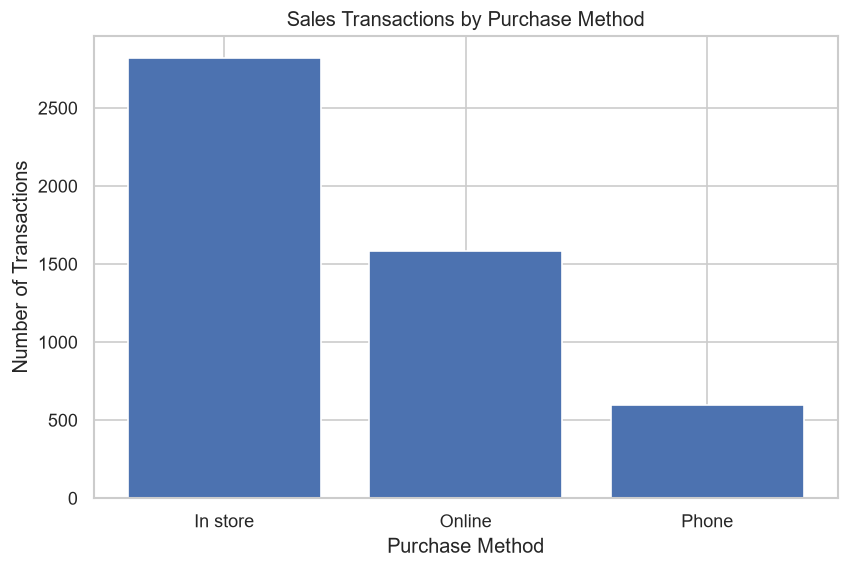

In [8]:
plt.figure(figsize=(8,5))

plt.bar(df["Purchase Method"], df["Total_Transactions"])

plt.title("Sales Transactions by Purchase Method")

plt.xlabel("Purchase Method")

plt.ylabel("Number of Transactions")

plt.show()

Question 4:
How many sales transactions were completed using coupons, and how many were completed without using coupons?

In [9]:
pipeline = [
    {
        "$group": {
            "_id": "$couponUsed",
            "Total_Transactions": {
                "$sum": 1
            }
        }
    },
    {
        "$sort": {
            "_id": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

df = pd.DataFrame(result)

df["_id"] = df["_id"].replace({
    True: "Coupon Used",
    False: "No Coupon"
})

df.rename(columns={"_id": "Coupon Status"}, inplace=True)

print(df)

  Coupon Status  Total_Transactions
0   Coupon Used                 477
1     No Coupon                4523


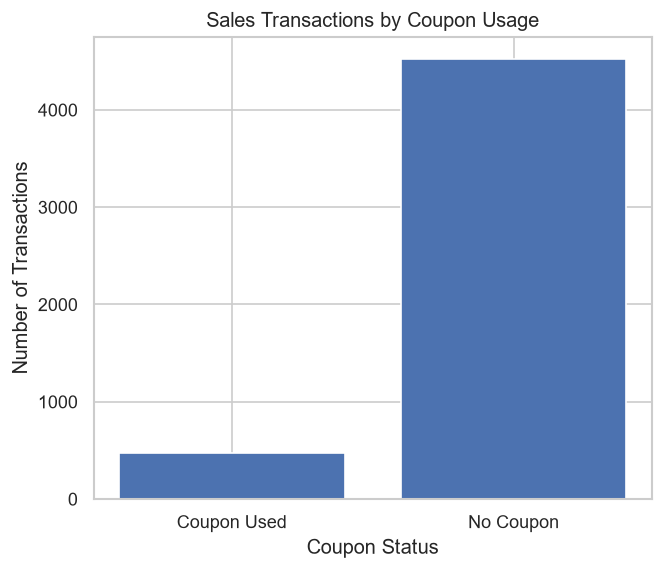

In [10]:
plt.figure(figsize=(6,5))

plt.bar(df["Coupon Status"], df["Total_Transactions"])

plt.title("Sales Transactions by Coupon Usage")

plt.xlabel("Coupon Status")

plt.ylabel("Number of Transactions")

plt.show()

Question 5 :
Question: How many sales transactions were recorded in each year?

In [11]:
pipeline = [
    {
        "$group": {
            "_id": {
                "$year": "$saleDate"
            },
            "Total_Transactions": {
                "$sum": 1
            }
        }
    },
    {
        "$sort": {
            "_id": 1
        }
    }
]

result = list(sales.aggregate(pipeline))

df = pd.DataFrame(result)

df.rename(columns={
    "_id": "Year"
}, inplace=True)

print(df)

   Year  Total_Transactions
0  2013                 991
1  2014                 941
2  2015                1006
3  2016                1010
4  2017                1052


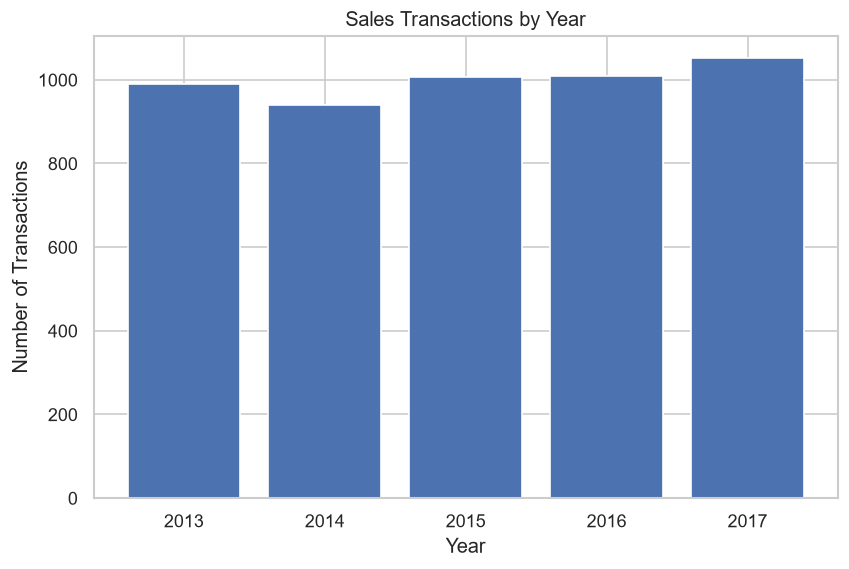

In [12]:
plt.figure(figsize=(8,5))

plt.bar(df["Year"].astype(str), df["Total_Transactions"])

plt.title("Sales Transactions by Year")

plt.xlabel("Year")

plt.ylabel("Number of Transactions")

plt.show()

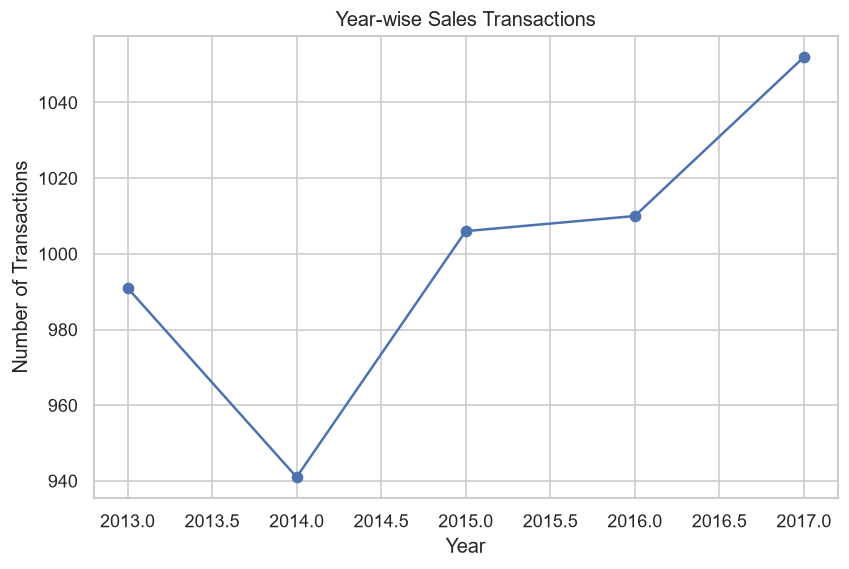

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Year"],
    df["Total_Transactions"],
    marker="o"
)

plt.title("Year-wise Sales Transactions")

plt.xlabel("Year")

plt.ylabel("Number of Transactions")

plt.grid(True)

plt.show()

Question 6 : How many sales transactions were recorded in each month, and are there any seasonal variations in transaction volume?

In [14]:
pipeline = [
    {
        "$group": {
            "_id": {
                "$month": "$saleDate"
            },
            "Total_Transactions": {
                "$sum": 1
            }
        }
    },
    {
        "$sort": {
            "_id": 1
        }
    }
]

result = list(sales.aggregate(pipeline))

df = pd.DataFrame(result)

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

df["Month"] = df["_id"].map(month_names)

df = df[["Month", "Total_Transactions"]]

print(df)

        Month  Total_Transactions
0     January                 444
1    February                 359
2       March                 419
3       April                 394
4         May                 426
5        June                 418
6        July                 437
7      August                 414
8   September                 389
9     October                 444
10   November                 423
11   December                 433


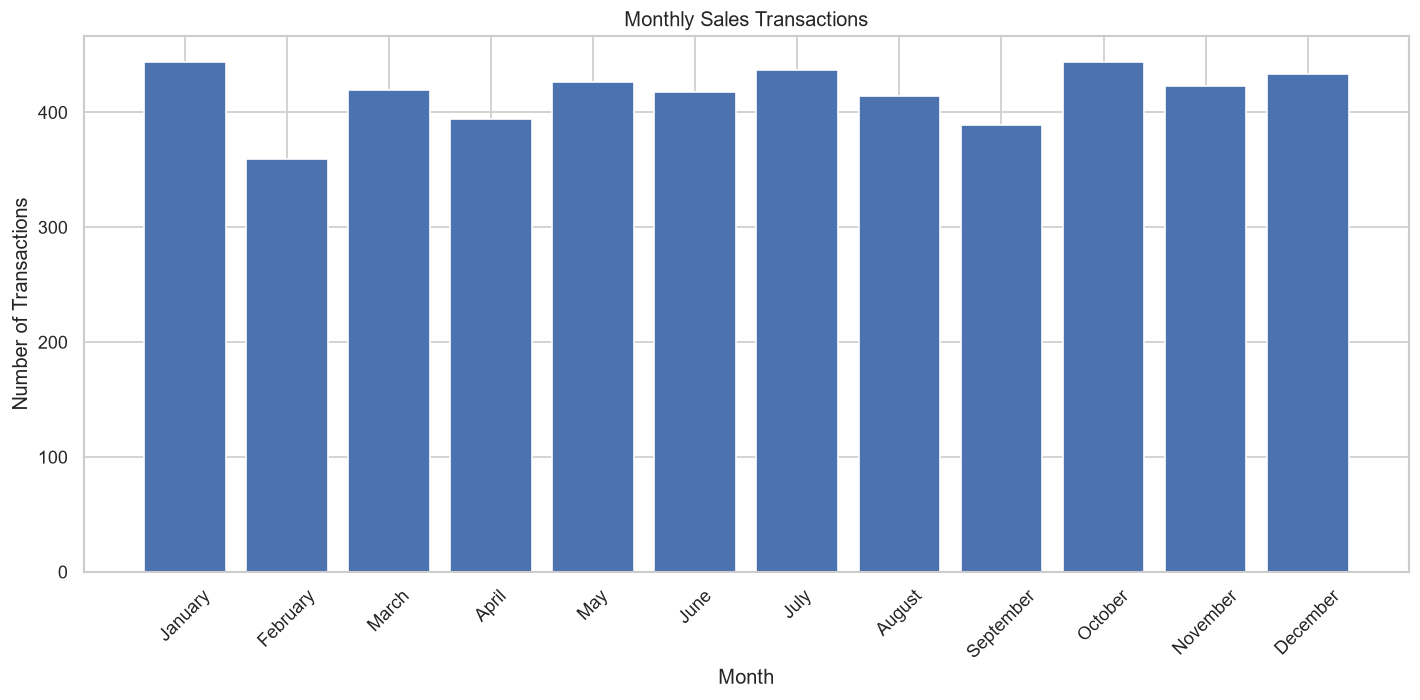

In [15]:
plt.figure(figsize=(12,6))

plt.bar(df["Month"], df["Total_Transactions"])

plt.title("Monthly Sales Transactions")

plt.xlabel("Month")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

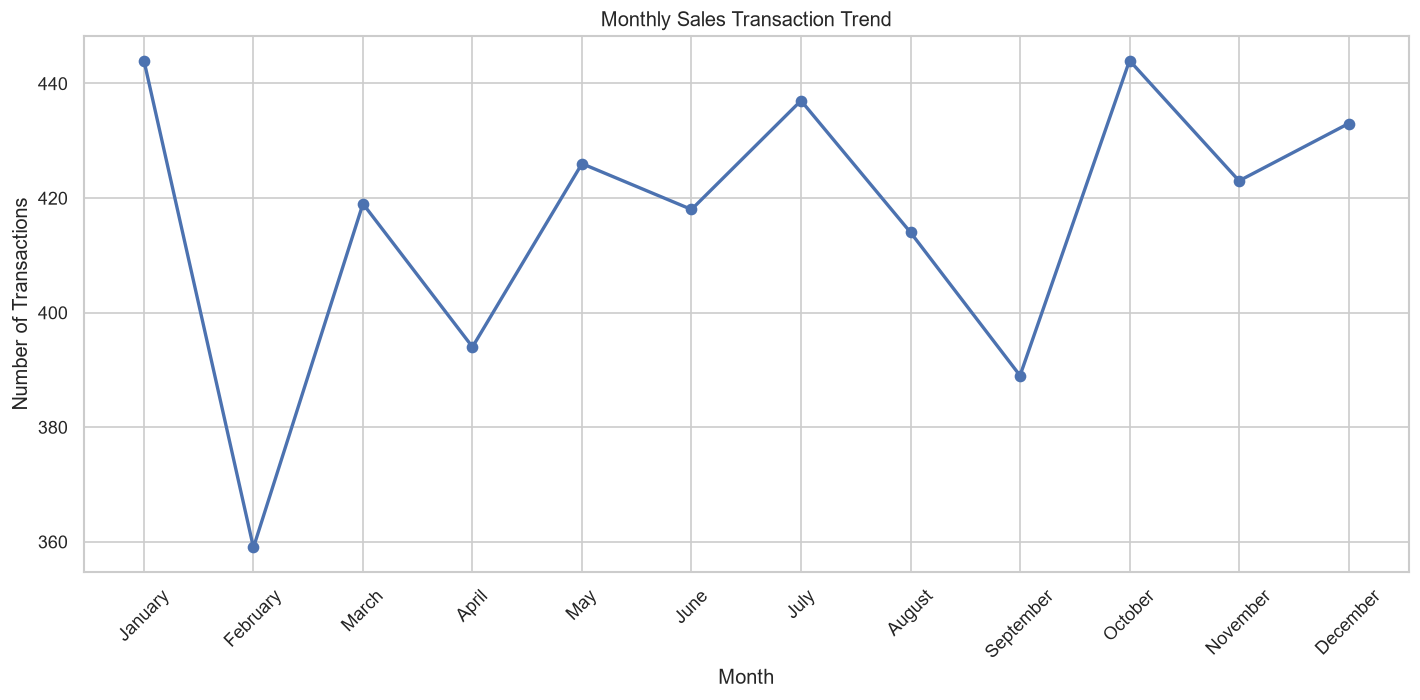

In [16]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Month"],
    df["Total_Transactions"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Transaction Trend")

plt.xlabel("Month")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

Question 7: How many unique products are sold by the business, and what are their names?

In [17]:
pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$items.name"
        }
    },
    {
        "$sort": {
            "_id": 1
        }
    }
]

result = list(sales.aggregate(pipeline))

product_names = [doc["_id"] for doc in result]

print("Total Unique Products:", len(product_names))

print("\nProduct Names:\n")

for product in product_names:
    print(product)

Total Unique Products: 7

Product Names:

backpack
binder
envelopes
laptop
notepad
pens
printer paper


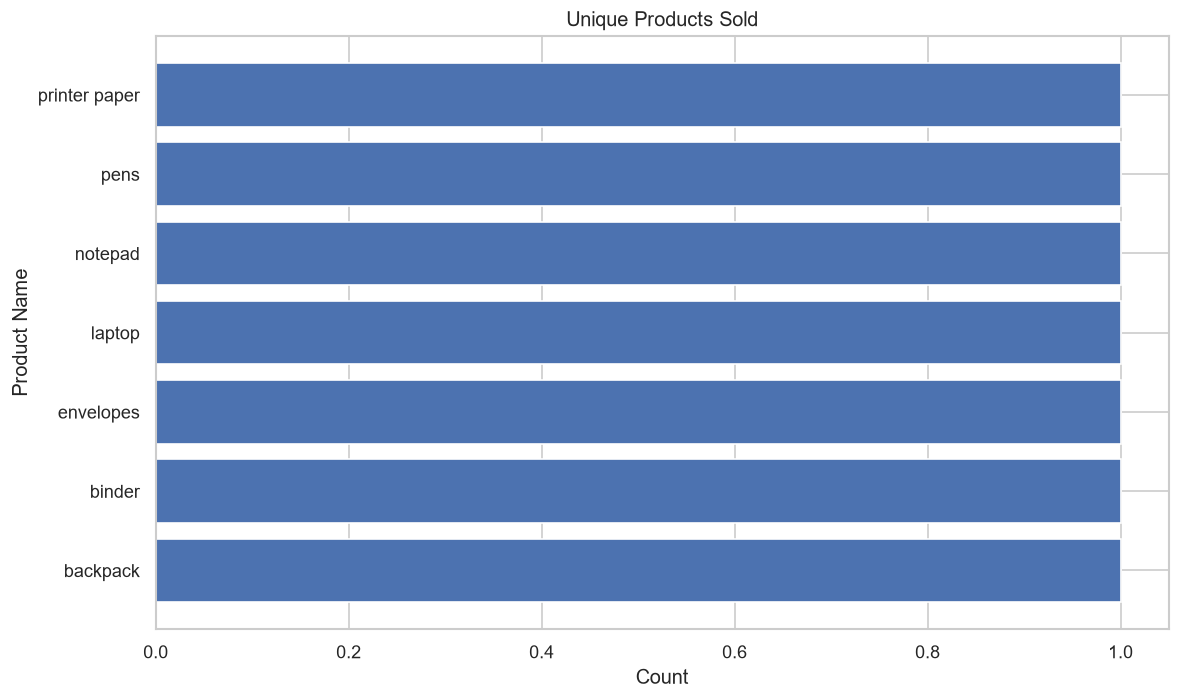

In [18]:
df = pd.DataFrame(product_names, columns=["Product Name"])

plt.figure(figsize=(10,6))

plt.barh(df["Product Name"], [1]*len(df))

plt.title("Unique Products Sold")

plt.xlabel("Count")

plt.ylabel("Product Name")

plt.tight_layout()

plt.show()

Question 8
Question: What is the average customer satisfaction rating of all customers in the dataset?

In [19]:
pipeline = [
    {
        "$group": {
            "_id": None,
            "Average_Rating": {
                "$avg": "$customer.satisfaction"
            }
        }
    }
]

result = list(sales.aggregate(pipeline))

average_rating = round(result[0]["Average_Rating"], 2)

print("Average Customer Satisfaction Rating:", average_rating)

Average Customer Satisfaction Rating: 3.79


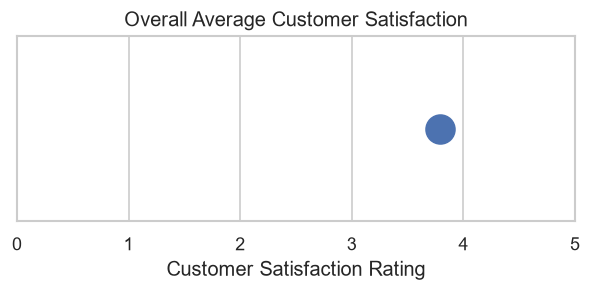

In [21]:
plt.figure(figsize=(6,2))

plt.scatter(
    average_rating,
    1,
    s=300
)

plt.xlim(0,5)

plt.yticks([])

plt.xlabel("Customer Satisfaction Rating")

plt.title("Overall Average Customer Satisfaction")

plt.grid(True)

plt.show()

Question 9 :
Question: Which products have the highest total quantity sold across all sales transactions?

In [22]:
pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$items.name",
            "Total_Quantity_Sold": {
                "$sum": "$items.quantity"
            }
        }
    },
    {
        "$sort": {
            "Total_Quantity_Sold": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

df = pd.DataFrame(result)

df.rename(columns={
    "_id": "Product Name"
}, inplace=True)

print(df)

    Product Name  Total_Quantity_Sold
0         binder                25493
1      envelopes                25078
2        notepad                20727
3           pens                13766
4  printer paper                12092
5       backpack                 6918
6         laptop                 6793


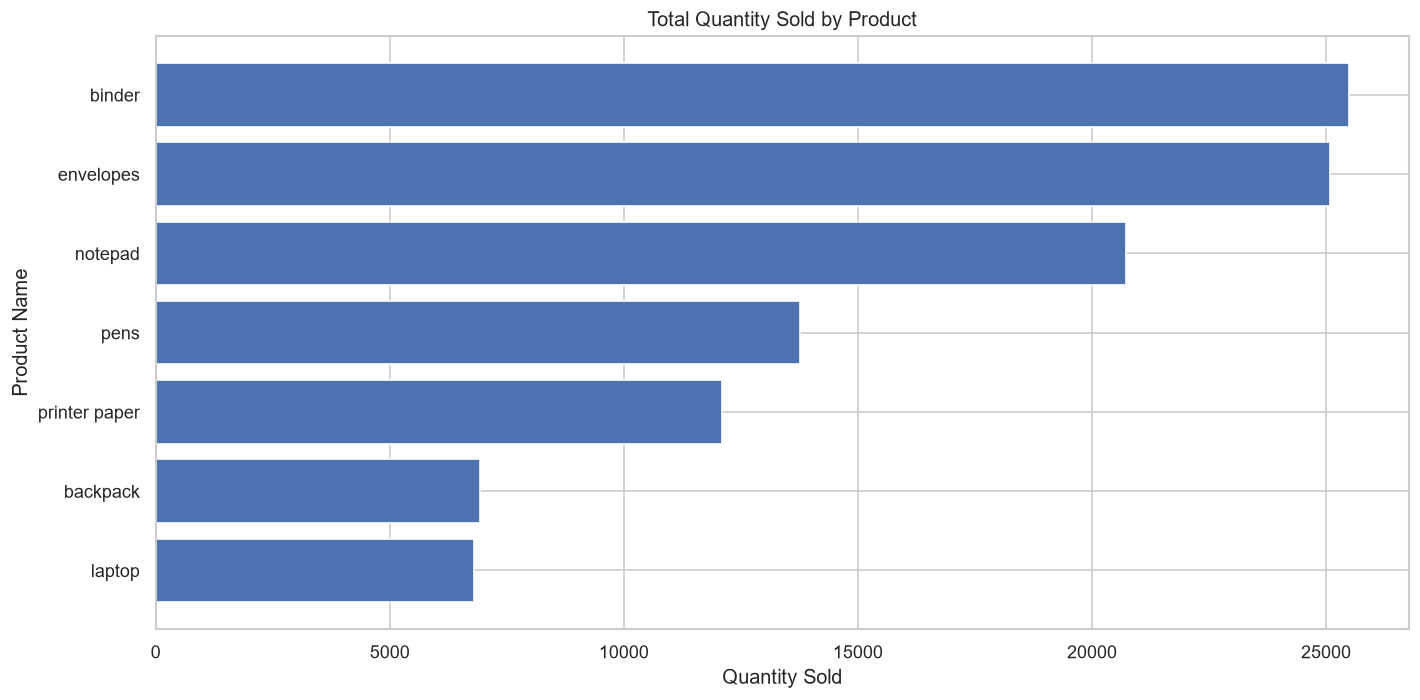

In [23]:
plt.figure(figsize=(12,6))

plt.barh(
    df["Product Name"],
    df["Total_Quantity_Sold"]
)

plt.title("Total Quantity Sold by Product")

plt.xlabel("Quantity Sold")

plt.ylabel("Product Name")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Question 10
Question: Which products generated the highest total sales revenue across all sales transactions?

In [25]:
from bson.decimal128 import Decimal128

pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$items.name",
            "Total_Revenue": {
                "$sum": {
                    "$multiply": [
                        "$items.quantity",
                        "$items.price"
                    ]
                }
            }
        }
    },
    {
        "$sort": {
            "Total_Revenue": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

# Convert Decimal128 to float
for doc in result:
    doc["Total_Revenue"] = float(doc["Total_Revenue"].to_decimal())

df = pd.DataFrame(result)

df.rename(columns={"_id": "Product Name"}, inplace=True)

print(df)

    Product Name  Total_Revenue
0         laptop     6775977.07
1       backpack      817374.10
2           pens      581843.27
3         binder      511644.57
4        notepad      463615.48
5      envelopes      376658.49
6  printer paper      367459.29


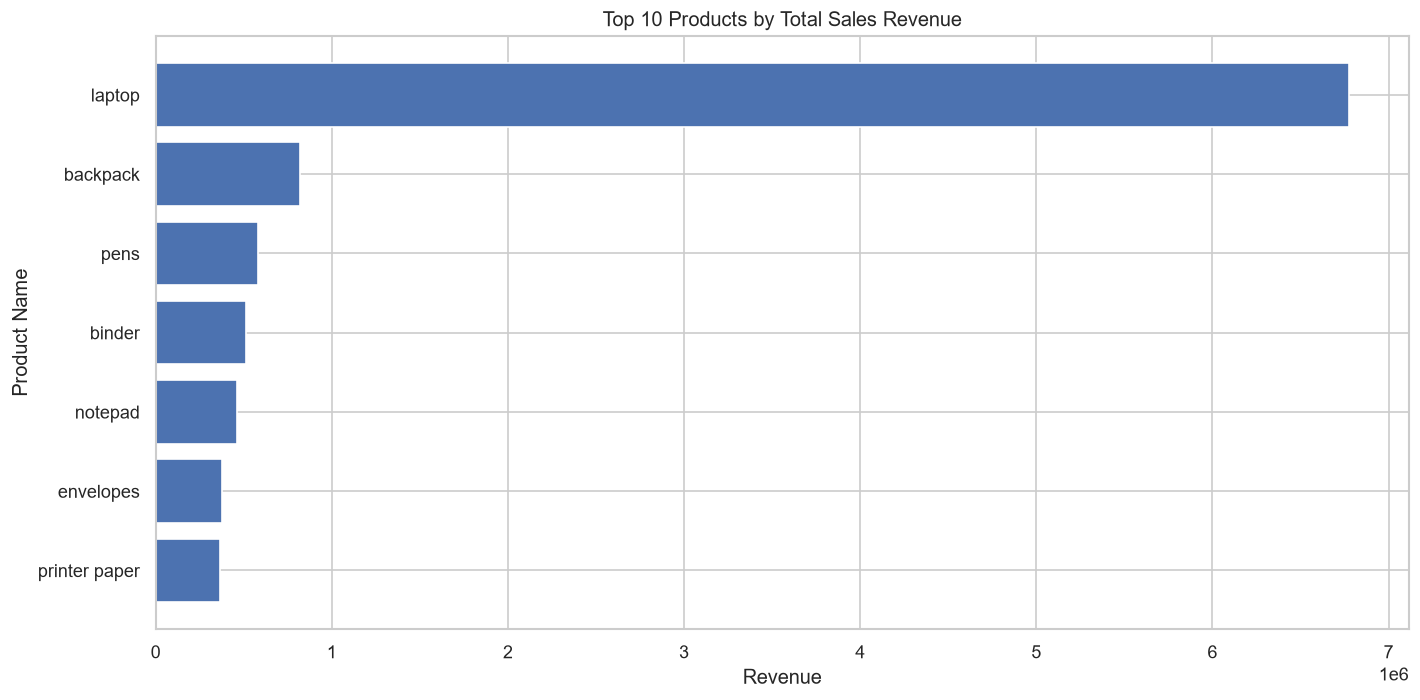

In [26]:
top10 = df.head(10)

plt.figure(figsize=(12,6))

plt.barh(top10["Product Name"], top10["Total_Revenue"])

plt.title("Top 10 Products by Total Sales Revenue")

plt.xlabel("Revenue")

plt.ylabel("Product Name")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Question 11
Question: Which store locations generated the highest total sales revenue?

In [27]:
pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$storeLocation",
            "Total_Revenue": {
                "$sum": {
                    "$multiply": [
                        "$items.quantity",
                        "$items.price"
                    ]
                }
            }
        }
    },
    {
        "$sort": {
            "Total_Revenue": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

# Convert Decimal128 to float
for doc in result:
    doc["Total_Revenue"] = float(doc["Total_Revenue"].to_decimal())

df = pd.DataFrame(result)

df.rename(columns={
    "_id": "Store Location"
}, inplace=True)

print(df)

  Store Location  Total_Revenue
0         Denver     2921009.92
1        Seattle     2255947.69
2         London     1583066.79
3         Austin     1445603.11
4       New York     1016059.59
5      San Diego      672885.17


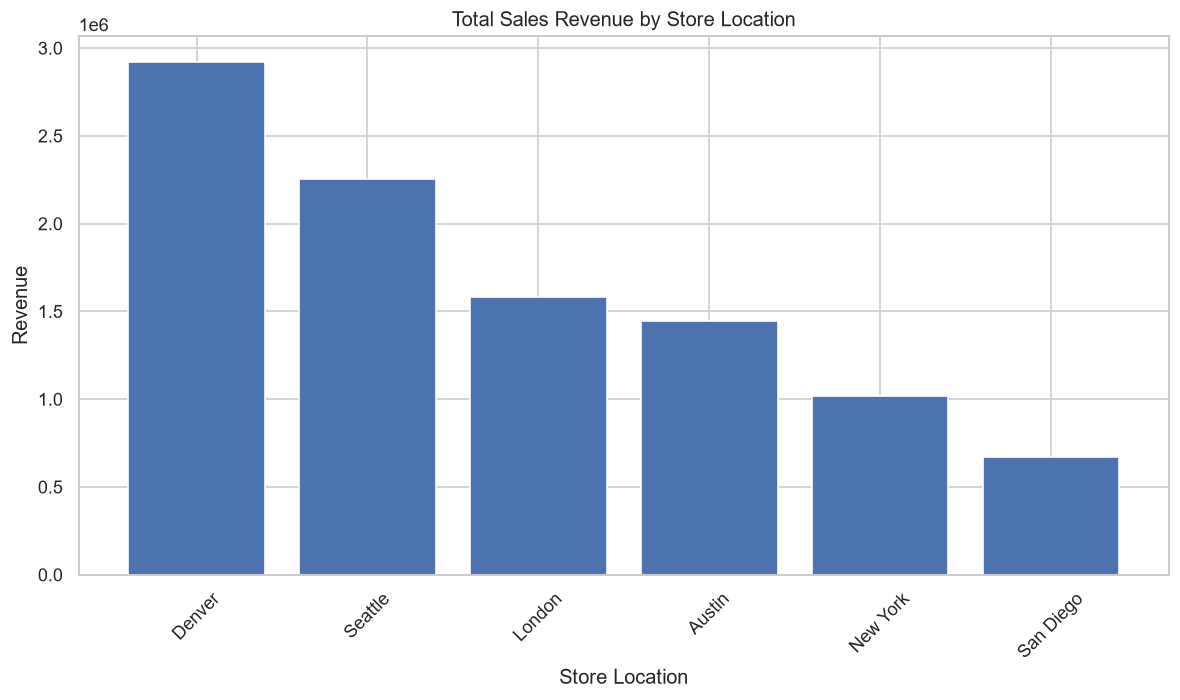

In [28]:
plt.figure(figsize=(10,6))

plt.bar(
    df["Store Location"],
    df["Total_Revenue"]
)

plt.title("Total Sales Revenue by Store Location")

plt.xlabel("Store Location")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Question 12
Question: How much total sales revenue was generated through each purchase method?

In [29]:
pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$purchaseMethod",
            "Total_Revenue": {
                "$sum": {
                    "$multiply": [
                        "$items.quantity",
                        "$items.price"
                    ]
                }
            }
        }
    },
    {
        "$sort": {
            "Total_Revenue": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

# Convert Decimal128 to float
for doc in result:
    doc["Total_Revenue"] = float(doc["Total_Revenue"].to_decimal())

df = pd.DataFrame(result)

df.rename(columns={
    "_id": "Purchase Method"
}, inplace=True)

print(df)

  Purchase Method  Total_Revenue
0        In store     5619138.67
1          Online     3163814.67
2           Phone     1111618.93


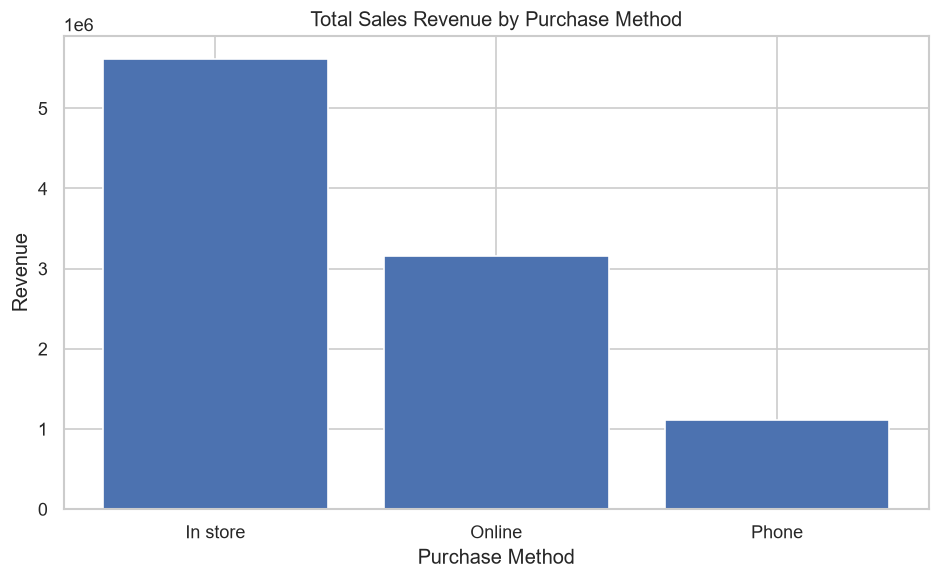

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    df["Purchase Method"],
    df["Total_Revenue"]
)

plt.title("Total Sales Revenue by Purchase Method")

plt.xlabel("Purchase Method")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

Question 13

Question: What is the average transaction value for each store location?

In [31]:
pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": {
                "saleId": "$_id",
                "storeLocation": "$storeLocation"
            },
            "Transaction_Value": {
                "$sum": {
                    "$multiply": [
                        "$items.quantity",
                        "$items.price"
                    ]
                }
            }
        }
    },
    {
        "$group": {
            "_id": "$_id.storeLocation",
            "Average_Transaction_Value": {
                "$avg": "$Transaction_Value"
            }
        }
    },
    {
        "$sort": {
            "Average_Transaction_Value": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

# Convert Decimal128 to float
for doc in result:
    doc["Average_Transaction_Value"] = float(
        doc["Average_Transaction_Value"].to_decimal()
    )

df = pd.DataFrame(result)

df.rename(columns={
    "_id": "Store Location"
}, inplace=True)

print(df)

  Store Location  Average_Transaction_Value
0         Austin                2138.466139
1       New York                2028.063054
2         London                1993.786889
3        Seattle                1989.371861
4      San Diego                1944.754827
5         Denver                1885.739135


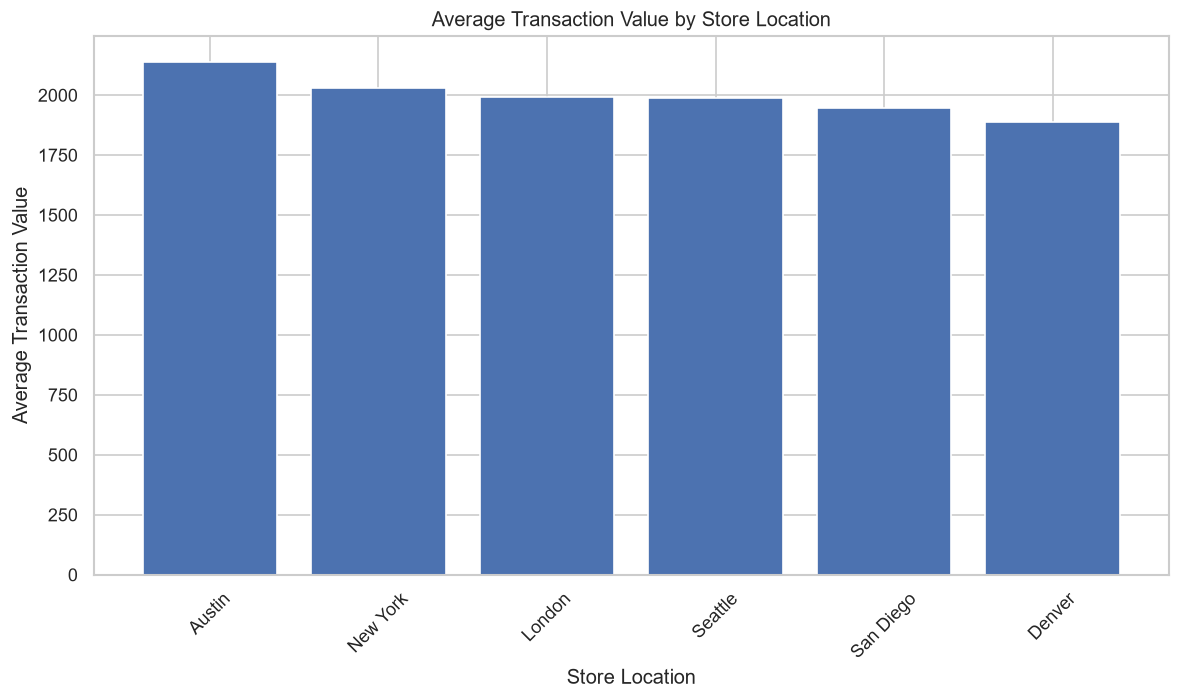

In [32]:
plt.figure(figsize=(10,6))

plt.bar(
    df["Store Location"],
    df["Average_Transaction_Value"]
)

plt.title("Average Transaction Value by Store Location")

plt.xlabel("Store Location")

plt.ylabel("Average Transaction Value")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Question 14

Question: Which products generated the highest sales revenue from transactions where a coupon was used?

In [33]:
pipeline = [
    {
        "$match": {
            "couponUsed": True
        }
    },
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$items.name",
            "Total_Revenue": {
                "$sum": {
                    "$multiply": [
                        "$items.quantity",
                        "$items.price"
                    ]
                }
            }
        }
    },
    {
        "$sort": {
            "Total_Revenue": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

# Convert Decimal128 to float
for doc in result:
    doc["Total_Revenue"] = float(doc["Total_Revenue"].to_decimal())

df = pd.DataFrame(result)

df.rename(columns={
    "_id": "Product Name"
}, inplace=True)

print(df)

    Product Name  Total_Revenue
0         laptop      663674.10
1       backpack       90102.89
2           pens       51731.62
3         binder       49139.69
4        notepad       44703.95
5      envelopes       35748.30
6  printer paper       35297.13


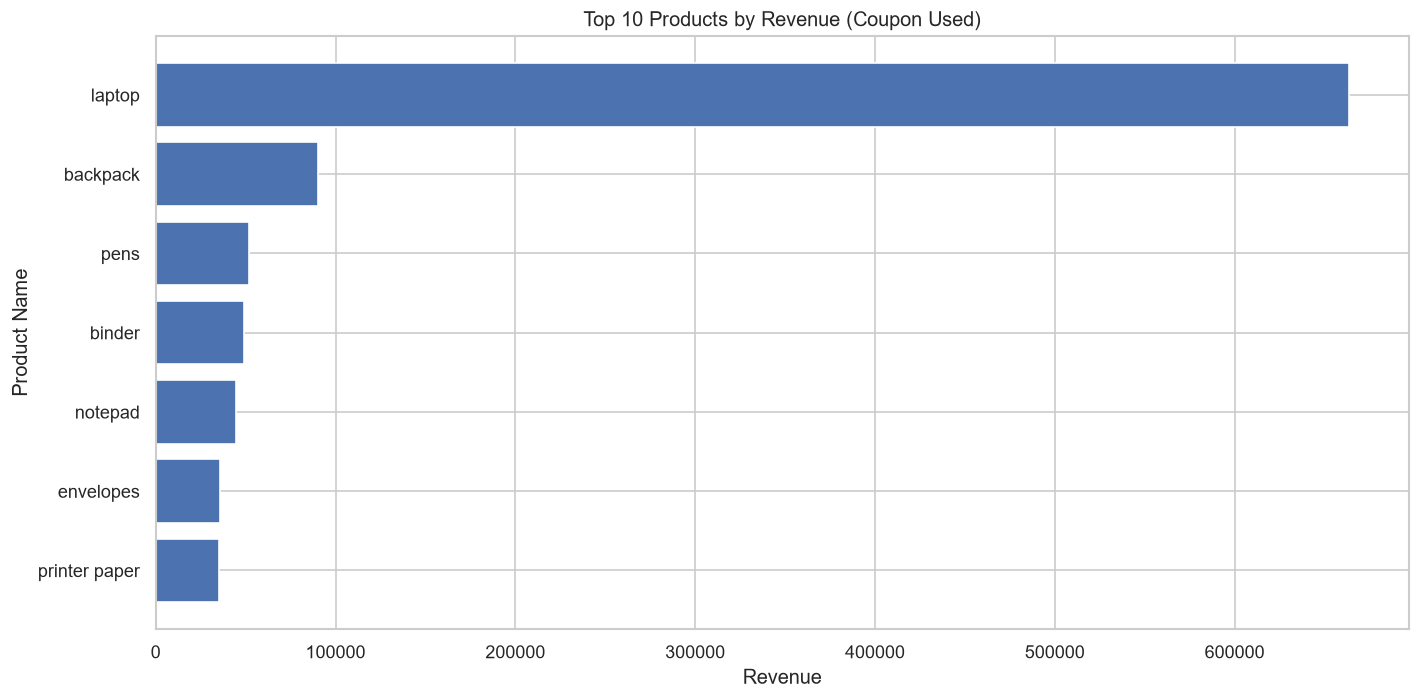

In [34]:
top10 = df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["Product Name"],
    top10["Total_Revenue"]
)

plt.title("Top 10 Products by Revenue (Coupon Used)")

plt.xlabel("Revenue")

plt.ylabel("Product Name")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Question 15

Question: What is the average selling price of each product?

In [35]:
pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$items.name",
            "Average_Selling_Price": {
                "$avg": "$items.price"
            }
        }
    },
    {
        "$sort": {
            "Average_Selling_Price": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

# Convert Decimal128 to float
for doc in result:
    doc["Average_Selling_Price"] = float(
        doc["Average_Selling_Price"].to_decimal()
    )

df = pd.DataFrame(result)

df.rename(columns={
    "_id": "Product Name"
}, inplace=True)

print(df)

    Product Name  Average_Selling_Price
0         laptop             992.152008
1       backpack             118.408341
2           pens              42.239006
3  printer paper              30.269484
4        notepad              22.425405
5         binder              20.027419
6      envelopes              15.020220


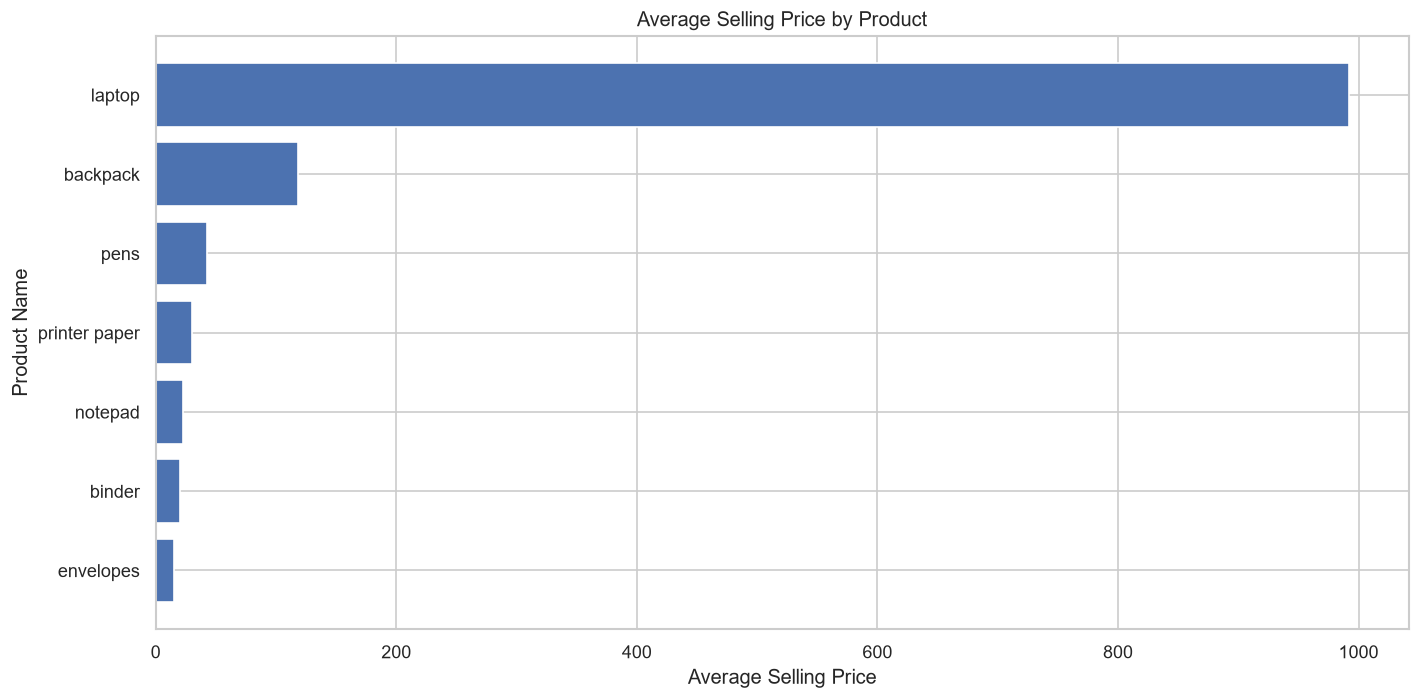

In [36]:
plt.figure(figsize=(12,6))

plt.barh(
    df["Product Name"],
    df["Average_Selling_Price"]
)

plt.title("Average Selling Price by Product")

plt.xlabel("Average Selling Price")

plt.ylabel("Product Name")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Question 16

Question: How can we calculate the total value of each sales transaction using MongoDB Aggregation?

In [37]:
pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$_id",
            "Store_Location": {
                "$first": "$storeLocation"
            },
            "Purchase_Method": {
                "$first": "$purchaseMethod"
            },
            "Transaction_Value": {
                "$sum": {
                    "$multiply": [
                        "$items.quantity",
                        "$items.price"
                    ]
                }
            }
        }
    },
    {
        "$sort": {
            "Transaction_Value": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

# Convert Decimal128 to float
for doc in result:
    doc["Transaction_Value"] = float(doc["Transaction_Value"].to_decimal())

df = pd.DataFrame(result)

df.rename(columns={
    "_id": "Transaction ID"
}, inplace=True)

print(df)

                Transaction ID Store_Location Purchase_Method  Transaction_Value
0     5bd761dcae323e45a93cd1dd         London           Phone            9385.19
1     5bd761ddae323e45a93cd537         London        In store            9105.13
2     5bd761deae323e45a93cde98       New York        In store            9005.51
3     5bd761ddae323e45a93cd810       New York          Online            8998.43
4     5bd761ddae323e45a93cd6fd        Seattle        In store            8989.94
...                        ...            ...             ...                ...
4995  5bd761ddae323e45a93cd69b        Seattle        In store               5.53
4996  5bd761deae323e45a93ce021         Denver        In store               5.49
4997  5bd761ddae323e45a93cd5a1         Denver        In store               5.33
4998  5bd761ddae323e45a93cd814         Denver        In store               5.29
4999  5bd761dcae323e45a93cd29a         London        In store               5.00

[5000 rows x 4 columns]


Question 17
Question: How many sales transactions are classified as High Value and Low Value based on their transaction amount?

In [38]:
pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$_id",
            "Transaction_Value": {
                "$sum": {
                    "$multiply": [
                        "$items.quantity",
                        "$items.price"
                    ]
                }
            }
        }
    },
    {
        "$project": {
            "Transaction_Value": 1,
            "Category": {
                "$cond": {
                    "if": {"$gte": ["$Transaction_Value", 1000]},
                    "then": "High Value",
                    "else": "Low Value"
                }
            }
        }
    },
    {
        "$group": {
            "_id": "$Category",
            "Total_Transactions": {
                "$sum": 1
            }
        }
    },
    {
        "$sort": {
            "Total_Transactions": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

df = pd.DataFrame(result)

df.rename(columns={"_id": "Transaction Category"}, inplace=True)

print(df)

  Transaction Category  Total_Transactions
0           High Value                2598
1            Low Value                2402


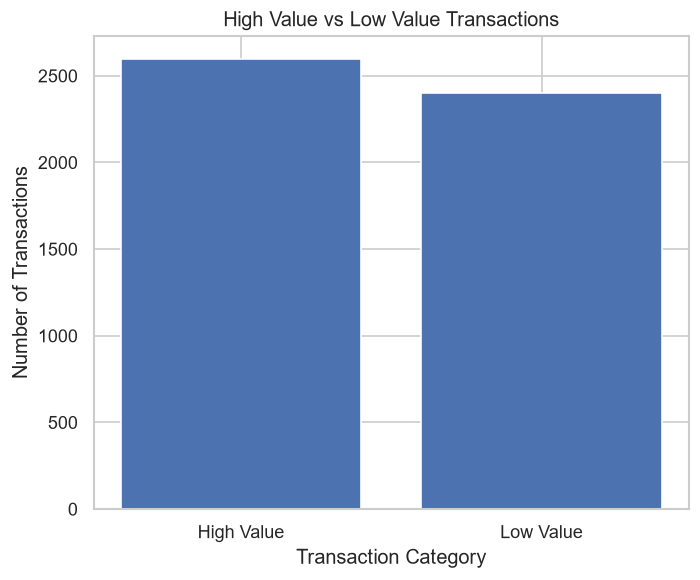

In [39]:
plt.figure(figsize=(6,5))

plt.bar(
    df["Transaction Category"],
    df["Total_Transactions"]
)

plt.title("High Value vs Low Value Transactions")

plt.xlabel("Transaction Category")

plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.show()

Question 18

Question: How are sales transactions distributed across different transaction value ranges?

In [40]:
pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$_id",
            "Transaction_Value": {
                "$sum": {
                    "$multiply": [
                        "$items.quantity",
                        "$items.price"
                    ]
                }
            }
        }
    }
]

result = list(sales.aggregate(pipeline))

# Convert Decimal128 to float
transaction_values = [
    float(doc["Transaction_Value"].to_decimal())
    for doc in result
]

df = pd.DataFrame({
    "Transaction_Value": transaction_values
})

# Create transaction value ranges
bins = [0, 250, 500, 750, 1000, 1500, 2000, 3000]
labels = [
    "0-250",
    "251-500",
    "501-750",
    "751-1000",
    "1001-1500",
    "1501-2000",
    "2001-3000"
]

df["Range"] = pd.cut(
    df["Transaction_Value"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

range_counts = (
    df["Range"]
    .value_counts()
    .sort_index()
)

print(range_counts)

Range
0-250        872
251-500      663
501-750      499
751-1000     368
1001-1500    470
1501-2000    290
2001-3000    544
Name: count, dtype: int64


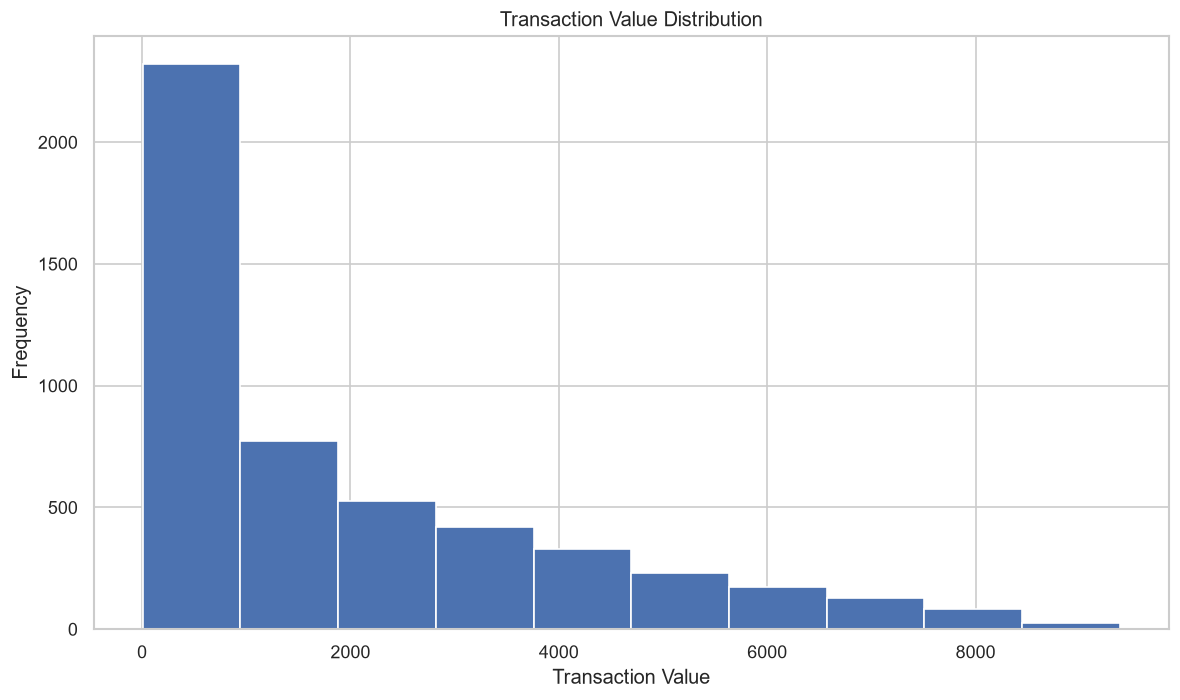

In [41]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Transaction_Value"],
    bins=10
)

plt.title("Transaction Value Distribution")

plt.xlabel("Transaction Value")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

Question 19
Question: How can multiple business summaries be generated simultaneously using MongoDB's $facet stage?

In [42]:
pipeline = [
    {
        "$facet": {

            "Purchase_Method_Summary": [
                {
                    "$group": {
                        "_id": "$purchaseMethod",
                        "Total_Transactions": {
                            "$sum": 1
                        }
                    }
                },
                {
                    "$sort": {
                        "Total_Transactions": -1
                    }
                }
            ],

            "Store_Location_Summary": [
                {
                    "$group": {
                        "_id": "$storeLocation",
                        "Total_Transactions": {
                            "$sum": 1
                        }
                    }
                },
                {
                    "$sort": {
                        "Total_Transactions": -1
                    }
                }
            ],

            "Coupon_Usage_Summary": [
                {
                    "$group": {
                        "_id": "$couponUsed",
                        "Total_Transactions": {
                            "$sum": 1
                        }
                    }
                }
            ]

        }
    }
]

result = list(sales.aggregate(pipeline))

from pprint import pprint

pprint(result)

[{'Coupon_Usage_Summary': [{'Total_Transactions': 4523, '_id': False},
                           {'Total_Transactions': 477, '_id': True}],
  'Purchase_Method_Summary': [{'Total_Transactions': 2819, '_id': 'In store'},
                              {'Total_Transactions': 1585, '_id': 'Online'},
                              {'Total_Transactions': 596, '_id': 'Phone'}],
  'Store_Location_Summary': [{'Total_Transactions': 1549, '_id': 'Denver'},
                             {'Total_Transactions': 1134, '_id': 'Seattle'},
                             {'Total_Transactions': 794, '_id': 'London'},
                             {'Total_Transactions': 676, '_id': 'Austin'},
                             {'Total_Transactions': 501, '_id': 'New York'},
                             {'Total_Transactions': 346, '_id': 'San Diego'}]}]


Question 20

Question: How can an Executive Business Dashboard be created using MongoDB Aggregation and Python?

In [43]:
from bson.decimal128 import Decimal128

# Total Transactions
total_transactions = sales.count_documents({})

# Total Revenue
pipeline = [
    {"$unwind": "$items"},
    {
        "$group": {
            "_id": None,
            "Total_Revenue": {
                "$sum": {
                    "$multiply": [
                        "$items.quantity",
                        "$items.price"
                    ]
                }
            }
        }
    }
]

revenue_result = list(sales.aggregate(pipeline))
total_revenue = float(revenue_result[0]["Total_Revenue"].to_decimal())

# Average Customer Satisfaction
pipeline = [
    {
        "$group": {
            "_id": None,
            "Average_Rating": {
                "$avg": "$customer.satisfaction"
            }
        }
    }
]

rating_result = list(sales.aggregate(pipeline))
average_rating = round(rating_result[0]["Average_Rating"], 2)

In [44]:
pipeline = [
    {
        "$group": {
            "_id": "$storeLocation",
            "Transactions": {
                "$sum": 1
            }
        }
    }
]

store_df = pd.DataFrame(list(sales.aggregate(pipeline)))
store_df.rename(columns={"_id":"Store"}, inplace=True)

In [45]:
pipeline = [
    {
        "$group":{
            "_id":"$purchaseMethod",
            "Count":{"$sum":1}
        }
    }
]

purchase_df = pd.DataFrame(list(sales.aggregate(pipeline)))
purchase_df.rename(columns={"_id":"Purchase Method"}, inplace=True)

In [46]:
pipeline = [
    {
        "$group":{
            "_id":"$couponUsed",
            "Count":{"$sum":1}
        }
    }
]

coupon_df = pd.DataFrame(list(sales.aggregate(pipeline)))

coupon_df["_id"] = coupon_df["_id"].replace({
    True:"Coupon Used",
    False:"No Coupon"
})

coupon_df.rename(columns={"_id":"Coupon Status"}, inplace=True)

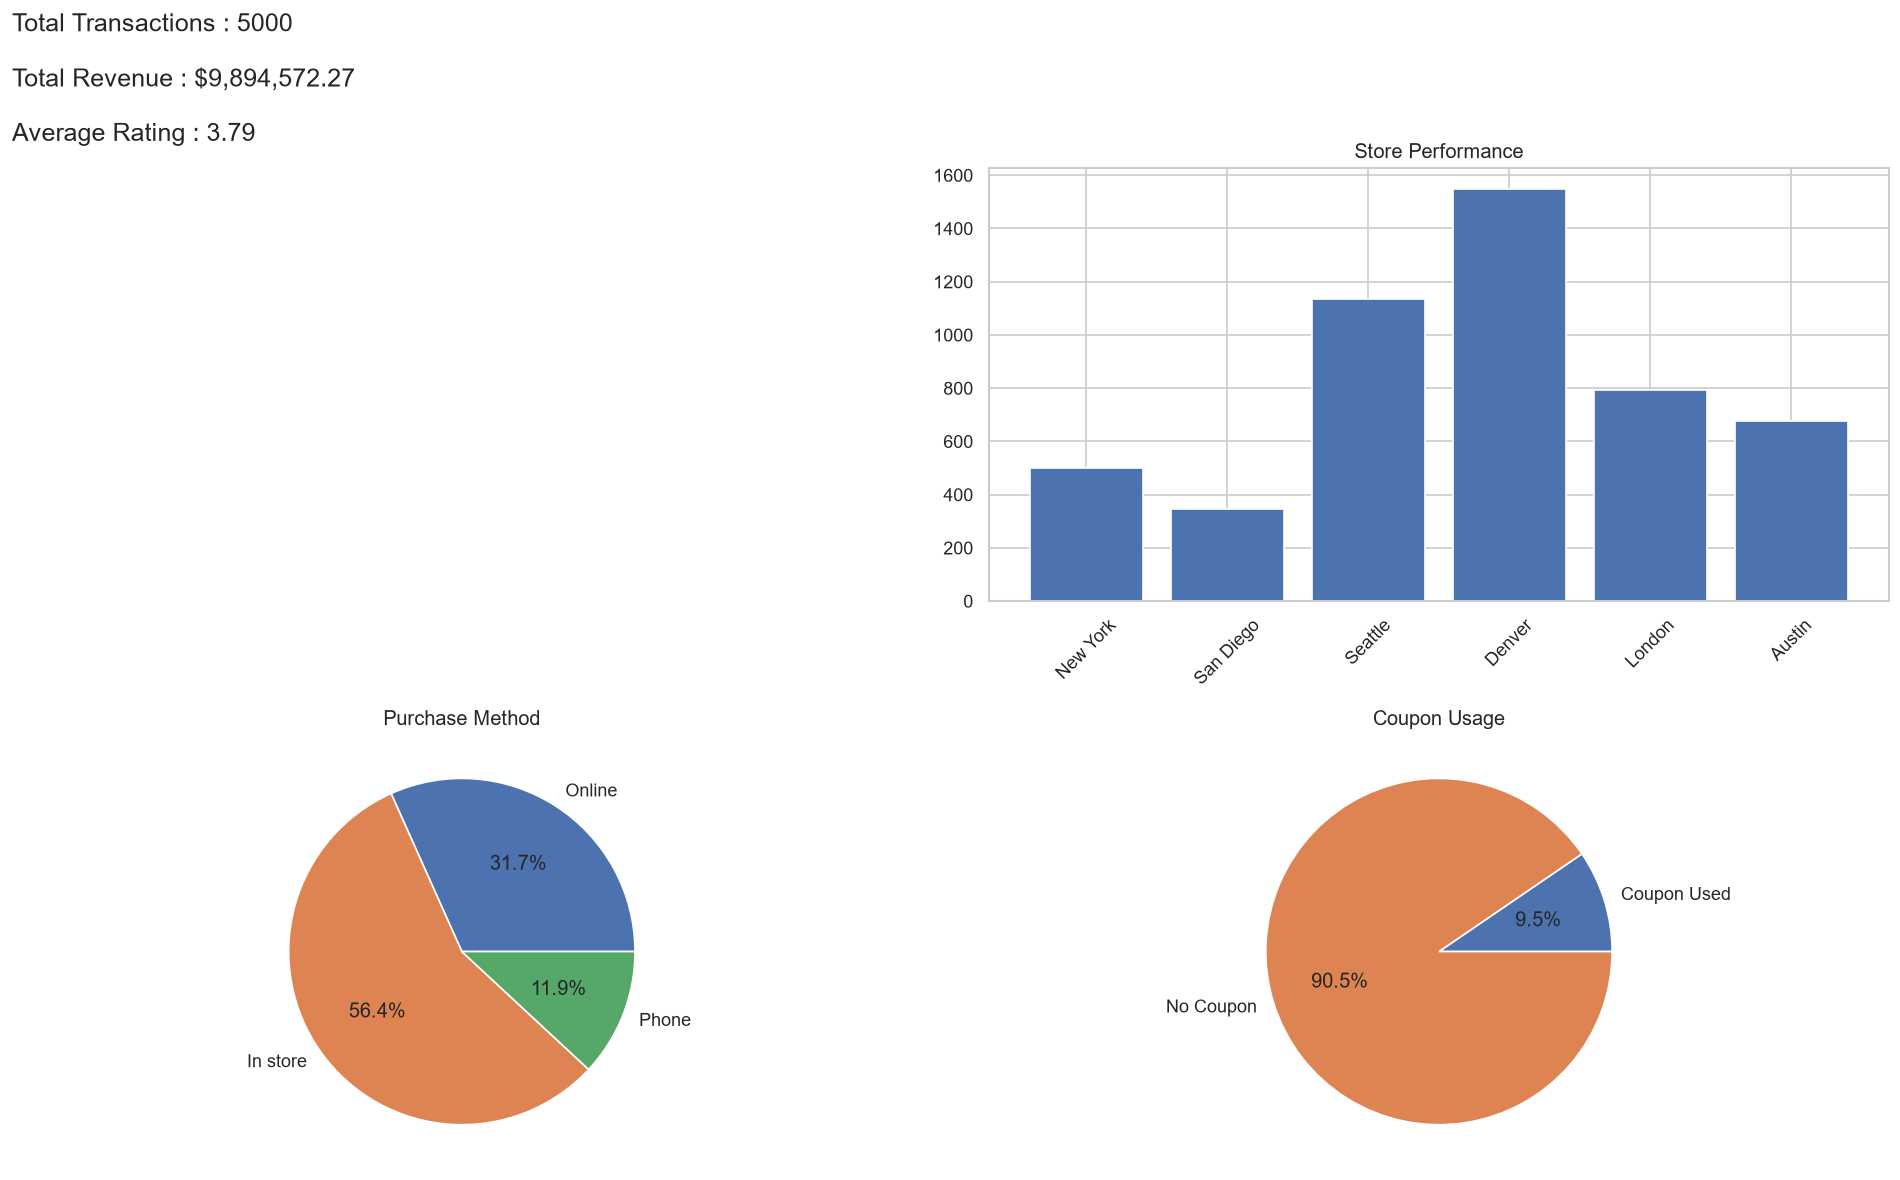

In [47]:
plt.figure(figsize=(16,10))

# KPI
plt.subplot(2,2,1)

plt.axis("off")

plt.text(
    0,
    1,
    f"""Total Transactions : {total_transactions}

Total Revenue : ${total_revenue:,.2f}

Average Rating : {average_rating}
""",
    fontsize=15
)

# Store Performance
plt.subplot(2,2,2)

plt.bar(
    store_df["Store"],
    store_df["Transactions"]
)

plt.title("Store Performance")

plt.xticks(rotation=45)

# Purchase Method
plt.subplot(2,2,3)

plt.pie(
    purchase_df["Count"],
    labels=purchase_df["Purchase Method"],
    autopct="%1.1f%%"
)

plt.title("Purchase Method")

# Coupon Usage
plt.subplot(2,2,4)

plt.pie(
    coupon_df["Count"],
    labels=coupon_df["Coupon Status"],
    autopct="%1.1f%%"
)

plt.title("Coupon Usage")

plt.tight_layout()

plt.show()